# 1. NGL Stations in Greece

Source: https://geodesy.unr.edu/velocities/midas.readme.txt

In [1]:
import pandas as pd

# Using the Eurasian plate-fixed reference frame (EU) since you are analyzing Greece
url = "https://geodesy.unr.edu/velocities/midas.EU.txt"

print("Downloading and parsing NGL MIDAS Velocity dataset...")

try:
    # 1. Read the space-separated table without an explicit header line
    df = pd.read_csv(url, sep=r'\s+', header=None)
    
    # 2. Map the columns precisely based on the README definitions (0-indexed)
    parsed_df = pd.DataFrame({
        'Station_ID': df.iloc[:, 0].astype(str).str.upper(),
        'Latitude':    pd.to_numeric(df.iloc[:, 24], errors='coerce'),  # col 25
        'Longitude':   pd.to_numeric(df.iloc[:, 25], errors='coerce'),  # col 26
        'Height_m':    pd.to_numeric(df.iloc[:, 26], errors='coerce')   # col 27
    })
    
    # 3. Handle NGL's -360 to 0 longitude mapping convention 
    # This ensures standard -180 to 180 coordinates for mapping tools
    parsed_df.loc[parsed_df['Longitude'] < -180, 'Longitude'] += 360.0
    
    # Drop rows that failed basic coordinate parsing
    parsed_df = parsed_df.dropna(subset=['Latitude', 'Longitude'])
    
    # 4. Filter specifically for the regional bounding box of Greece 
    greece_df = parsed_df[
        (parsed_df['Latitude'].between(34.0, 42.0)) & 
        (parsed_df['Longitude'].between(19.0, 29.0))
    ].copy()
    
    # 5. Export results
    greece_df.to_csv("NGL_Greece_Stations.csv", index=False)
    
    print("\n--- Processing Success! ---")
    print(f"Total global stations processed: {len(parsed_df)}")
    print(f"Total stations found inside Greece bounding box: {len(greece_df)}")
    print(f"Saved filtered data to: NGL_Greece_Stations.csv")
    print("\nSample of Greek stations with velocities (m/yr):")
    print(greece_df[['Station_ID', 'Latitude', 'Longitude', 'Height_m']].head())

except Exception as e:
    print(f"Failed to parse velocity file: {e}")


--- Processing Success! ---
Total global stations processed: 7584
Total stations found inside Greece bounding box: 270
Saved filtered data to: NGL_Greece_Stations.csv

Sample of Greek stations with velocities (m/yr):
    Station_ID   Latitude  Longitude   Height_m
547       ABEL  38.923189  21.214995  311.82536
583       AFY0  40.101070  23.434337  114.35081
585       AFYT  40.097136  23.435325  106.12496
594       AGNA  39.483652  21.846997  145.53231
599       AGRI  38.623995  21.409030  124.09188


/home/ubuntu_user/miniconda3/envs/OCM_packs/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


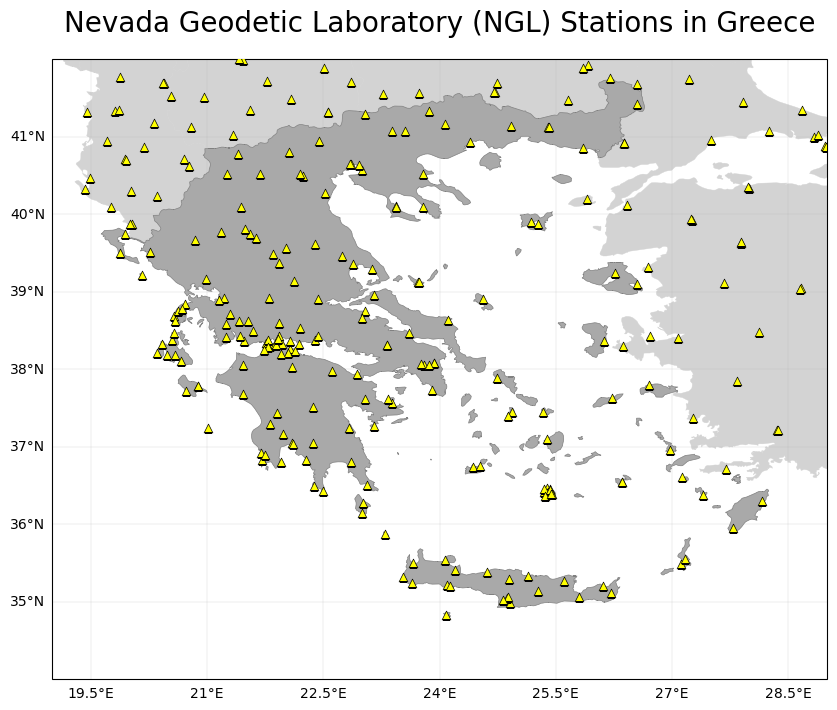

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# Load data
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")

# Clean columns
df["lat"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["lon"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["dep"] = pd.to_numeric(df["Height_m"], errors="coerce")

df = df.dropna(subset=["lat", "lon", "dep"])

# ----- Create Map -----
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Geographic extent around Greece
ax.set_extent([19, 29, 34, 42], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

# Add generic map features
ax.add_feature(cfeature.OCEAN, facecolor="white") #"aliceblue"

# ----- Highlight Greece Territory & Background Land -----
# 1. Download the Natural Earth country shapefile path
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()

# 2. Loop through countries and color them conditionally
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='gray', linewidth=0.5, zorder=2) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='lightgray', linewidth=0.3, zorder=1) #"powderblue"

# Optional gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, zorder=3)
gl.top_labels = False
gl.right_labels = False

# ----- Plot Stations (Red Triangles) -----
sc = ax.scatter(
    df["lon"],
    df["lat"],
    color="yellow", #"blueviolet"               # Makes all stations solid red
    marker="^",                # Changes markers to upward-pointing triangles
    s=40,                      # Adjust size of triangles if needed
    alpha=1,
    edgecolor="k",
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5                   # Forces triangles to sit on top of the land polygons
)

plt.title("Nevada Geodetic Laboratory (NGL) Stations in Greece", size=20, pad=20)
plt.savefig("Greece_NGL_Stations_Map.png", bbox_inches='tight', dpi=300)
plt.show()

# 2. Earthquakes in Greece $\geq Mw 4.5$ from 1997 to 2020

In [7]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy import read_events
import time

full_catalog = read_events("jan76_dec20.ndk")

start_time = UTCDateTime("1997-01-01T00:00:00")
end_time   = UTCDateTime("2021-01-01T00:00:00")

catalog = full_catalog.filter(
    "time >= %s" % start_time,
    "time <= %s" % end_time,
    "magnitude >= 4.5",
    "latitude >= 34",
    "latitude <= 42",
    "longitude >= 19",
    "longitude <= 29"
)

catalog.write("Greece_Seismicity.xml", format="QUAKEML")
print(len(catalog))

496


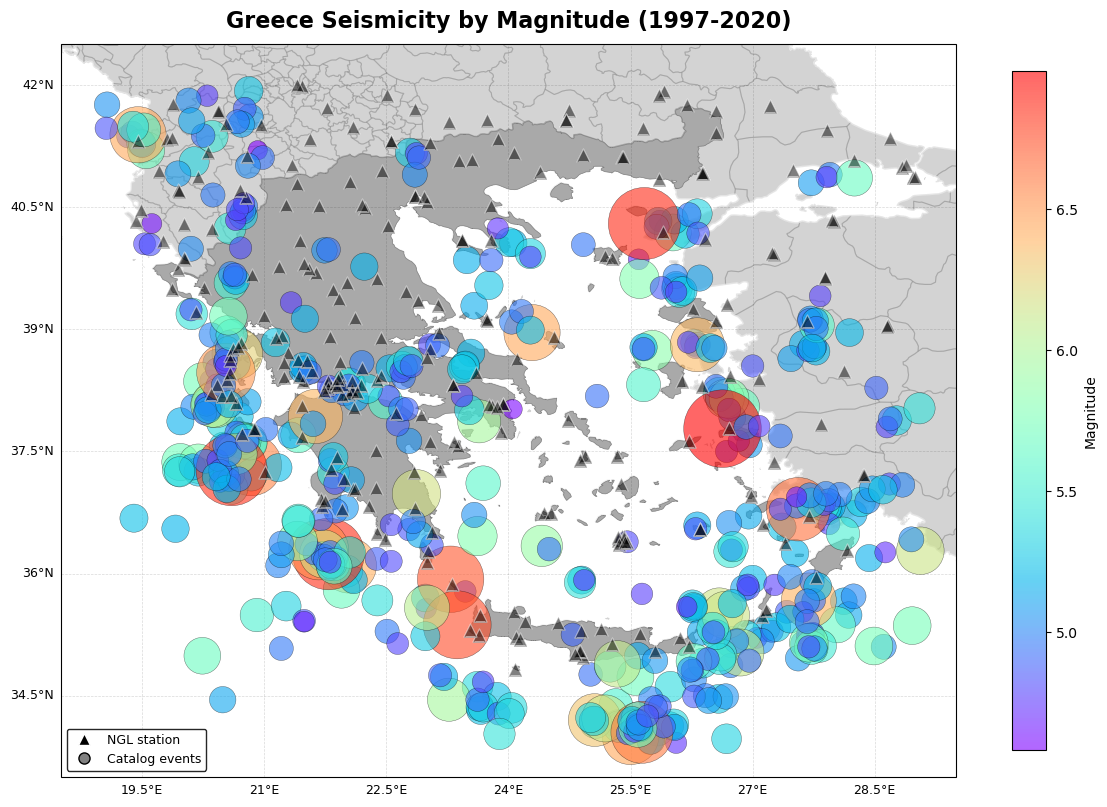

Map saved → Greece_Seismicity_Magnitudes_1997-2020.png


In [8]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# 4. Map the Catalogue and Stations

# Load data
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")

# Clean columns
df["sta_lats"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["sta_lons"] = pd.to_numeric(df["Longitude"], errors="coerce")

df = df.dropna(subset=["sta_lats", "sta_lons"])

# Collect catalog event coordinates and magnitudes
ev_lons, ev_lats, ev_mags, ev_deps = [], [], [], []
for ev in catalog:
    # Safely get the preferred origin and magnitude, or fallback to the first one
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    ev_lons.append(origin.longitude)
    ev_lats.append(origin.latitude)
    ev_mags.append(mag.mag)
    ev_deps.append(origin.depth / 1000.0 if origin.depth is not None else np.nan)  # m -> km

# ── Map extent (dynamically pad around stations AND events) ─────────────────
lon_min, lon_max = 18.5, 29.5
lat_min, lat_max = 33.5, 42.5

fig = plt.figure(figsize=(12, 10), facecolor="white")
ax = fig.add_subplot(
    1, 1, 1,
    projection=ccrs.PlateCarree(),
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# ── Built-in Vector Features ────────────────────────────────────────────────
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
ax.add_feature(cfeature.STATES.with_scale("10m"),
               linewidth=0.8, edgecolor="grey", facecolor="none", alpha=0.3)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"),
               linewidth=1.2, edgecolor="white", alpha=0.6)

# ----- Highlight Greece Territory & Background Land -----
# 1. Download the Natural Earth country shapefile path
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()

# 2. Loop through countries and color them conditionally
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='gray', linewidth=0.5, zorder=2) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='lightgray', linewidth=0.3, zorder=1) #"powderblue"

# ── Gridlines ───────────────────────────────────────────────────────────────
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black",
    alpha=0.15, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"color": "black", "fontsize": 9}
gl.ylabel_style = {"color": "black", "fontsize": 9}

outline = [pe.withStroke(linewidth=2.5, foreground="black")]

# ── Station markers ─────────────────────────────────────────────────────────
ax.scatter(
    df["sta_lons"], df["sta_lats"],
    transform=ccrs.PlateCarree(),
    s=90, marker="^",
    color="black", edgecolors="white", linewidths=0.8,
    zorder=5, label="Seismic station",
    alpha=0.5
)

# ── Plot Catalog Events  ────────────────────────────
# Scale circle size exponentially by magnitude for better visual hierarchy
sizes = [10 ** (float(m)/2)  for m in ev_mags] 

sc = ax.scatter(
    ev_lons, ev_lats,
    transform=ccrs.PlateCarree(),
    c=ev_mags,
    s=sizes, marker="o",
    cmap="rainbow",
    alpha=0.6, zorder=4, label="Catalog events",
    edgecolor="k",
    linewidth=0.3
)

plt.colorbar(sc, ax=ax, label="Magnitude", shrink=0.7)

# ── Legend & title ──────────────────────────────────────────────────────────

legend_elements = [
    Line2D(
        [0], [0],
        marker='^',
        color='w',
        label='NGL station',
        markerfacecolor='black',
        markeredgecolor='white',
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Catalog events',
        markerfacecolor='grey',
        markeredgecolor='black',
        markersize=8
    )
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower left",
    framealpha=0.85,
    frameon=True,
    fontsize=9,
    facecolor="white",
    edgecolor="black"
)

ax.set_title(
    "Greece Seismicity by Magnitude (1997-2020)",
    fontsize=16, fontweight="bold", color="black", pad=12,
)

ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("Greece_Seismicity_Magnitudes_1997-2020.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Map saved → Greece_Seismicity_Magnitudes_1997-2020.png")

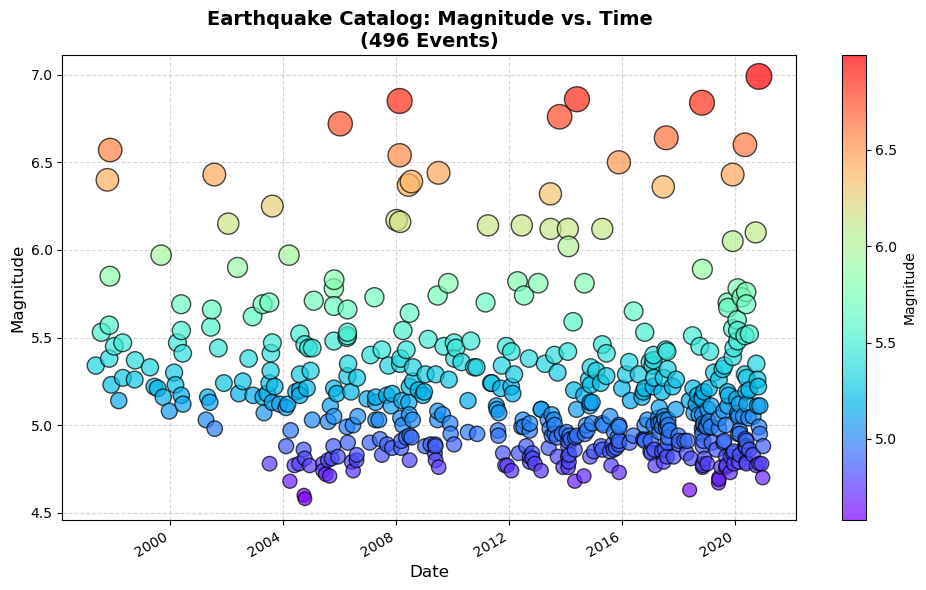

In [9]:
import matplotlib.dates as mdates

# 1. Magnitude Vs. Time Plot of the Earthquake Catalog

times = []
magnitudes = []

for event in catalog:
    # Ensure the event actually has origin and magnitude data
    if event.origins and event.magnitudes:
        
        # Use the preferred origin/magnitude if set, otherwise fallback to the first one
        origin = event.preferred_origin() or event.origins[0]
        mag = event.preferred_magnitude() or event.magnitudes[0]
        
        # Double check that the values aren't None before appending
        if origin.time is not None and mag.mag is not None:
            # CRITICAL: Matplotlib prefers standard Python datetime objects, 
            # so we use the .datetime attribute to convert ObsPy's UTCDateTime
            times.append(origin.time.datetime) 
            magnitudes.append(mag.mag)

# Plotting

fig, ax = plt.subplots(figsize=(10, 6))

# Create a scatter plot
# We scale the size (s) and color (c) of the dots based on their magnitude
scatter = ax.scatter(times, magnitudes, 
                     c=magnitudes,           # Color dots by magnitude
                     cmap='rainbow',          # A vibrant colormap
                     alpha=0.7,              # Slight transparency for overlapping dots
                     edgecolors='black',     # Clean borders
                     s=[(m)**3 for m in magnitudes], # Scale dot area exponentially
                     zorder=2)               # Ensure dots draw on top of the grid

# Add a colorbar matching our colormap
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Magnitude')

# Clean formatting and labels
ax.set_title(f"Earthquake Catalog: Magnitude vs. Time\n({len(times)} Events)", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Magnitude", fontsize=12)

# Format the x-axis dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # e.g., "Jan 2023"
fig.autofmt_xdate() # Auto-rotates the date labels so they don't overlap

# Add a subtle grid for readability
ax.grid(True, linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.savefig("Greece_Mag_vs_Time.png")
plt.show()

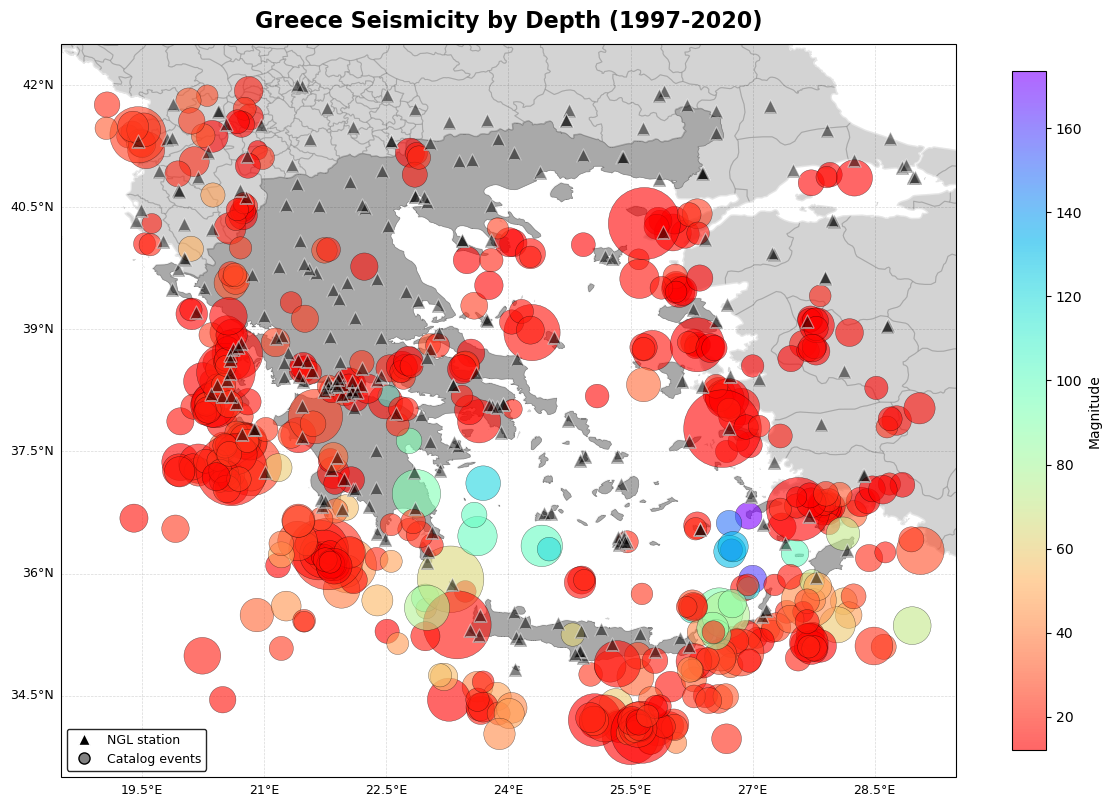

Map saved → Greece_Seismicity_Depths_1997-2020.png


In [10]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# 4. Map the Catalogue and Stations

# Load data
df = pd.read_csv("NGL_Greece_Stations.csv", sep=",")

# Clean columns
df["sta_lats"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["sta_lons"] = pd.to_numeric(df["Longitude"], errors="coerce")

df = df.dropna(subset=["sta_lats", "sta_lons"])

# Collect catalog event coordinates and magnitudes
ev_lons, ev_lats, ev_mags, ev_deps = [], [], [], []
for ev in catalog:
    # Safely get the preferred origin and magnitude, or fallback to the first one
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    ev_lons.append(origin.longitude)
    ev_lats.append(origin.latitude)
    ev_mags.append(mag.mag)
    ev_deps.append(origin.depth / 1000.0 if origin.depth is not None else np.nan)  # m -> km

# ── Map extent (dynamically pad around stations AND events) ─────────────────
lon_min, lon_max = 18.5, 29.5
lat_min, lat_max = 33.5, 42.5

fig = plt.figure(figsize=(12, 10), facecolor="white")
ax = fig.add_subplot(
    1, 1, 1,
    projection=ccrs.PlateCarree(),
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# ── Built-in Vector Features ────────────────────────────────────────────────
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
ax.add_feature(cfeature.STATES.with_scale("10m"),
               linewidth=0.8, edgecolor="grey", facecolor="none", alpha=0.3)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"),
               linewidth=1.2, edgecolor="white", alpha=0.6)

# ----- Highlight Greece Territory & Background Land -----
# 1. Download the Natural Earth country shapefile path
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()

# 2. Loop through countries and color them conditionally
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='gray', linewidth=0.5, zorder=2) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='lightgray', linewidth=0.3, zorder=1) #"powderblue"

# ── Gridlines ───────────────────────────────────────────────────────────────
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black",
    alpha=0.15, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"color": "black", "fontsize": 9}
gl.ylabel_style = {"color": "black", "fontsize": 9}

outline = [pe.withStroke(linewidth=2.5, foreground="black")]

# ── Station markers ─────────────────────────────────────────────────────────
ax.scatter(
    df["sta_lons"], df["sta_lats"],
    transform=ccrs.PlateCarree(),
    s=90, marker="^",
    color="black", edgecolors="white", linewidths=0.8,
    zorder=5, label="Seismic station",
    alpha=0.5
)

# ── Plot Catalog Events  ────────────────────────────
# Scale circle size exponentially by magnitude for better visual hierarchy
sizes = [10 ** (float(m)/2)  for m in ev_mags] 

sc = ax.scatter(
    ev_lons, ev_lats,
    transform=ccrs.PlateCarree(),
    c=ev_deps,
    s=sizes, marker="o",
    cmap="rainbow_r",
    alpha=0.6, zorder=4, label="Catalog events",
    edgecolor="k",
    linewidth=0.3
)

plt.colorbar(sc, ax=ax, label="Magnitude", shrink=0.7)
cbar.ax.invert_yaxis()

# ── Legend & title ──────────────────────────────────────────────────────────

legend_elements = [
    Line2D(
        [0], [0],
        marker='^',
        color='w',
        label='NGL station',
        markerfacecolor='black',
        markeredgecolor='white',
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Catalog events',
        markerfacecolor='grey',
        markeredgecolor='black',
        markersize=8
    )
]

legend = ax.legend(
    handles=legend_elements,
    loc="lower left",
    framealpha=0.85,
    frameon=True,
    fontsize=9,
    facecolor="white",
    edgecolor="black"
)

ax.set_title(
    "Greece Seismicity by Depth (1997-2020)",
    fontsize=16, fontweight="bold", color="black", pad=12,
)

ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("Greece_Seismicity_Depths_1997-2020.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Map saved → Greece_Seismicity_Depths_1997-2020.png")

Look for the Mc range where the b-value plateaus — that's the reliable region.


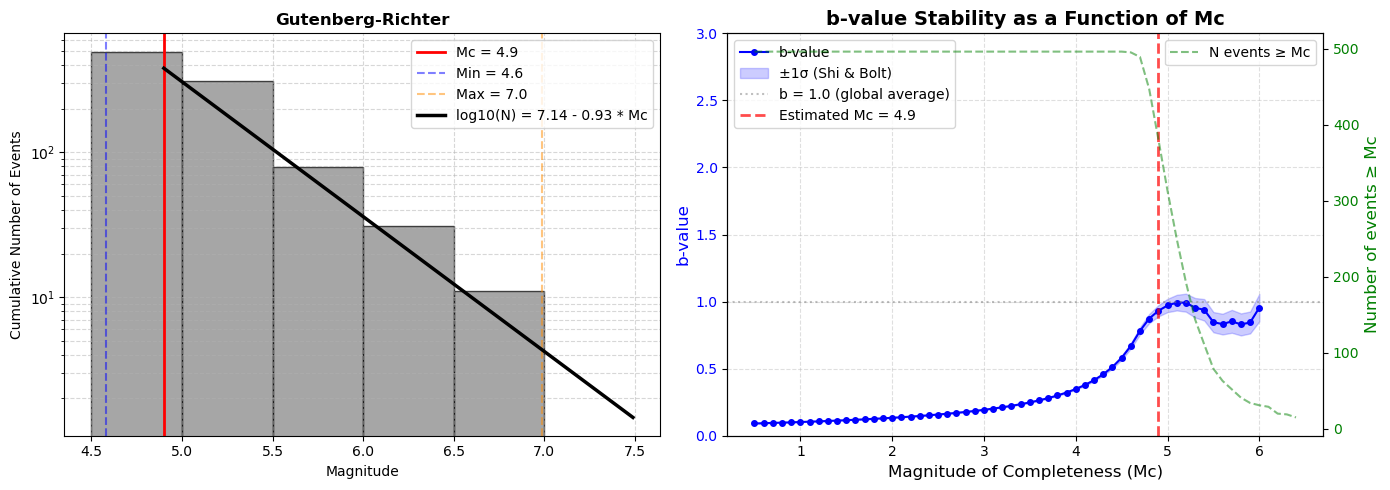

In [24]:
# 2. Gutenberg-Richter Plot

# =====================================================================
# DATA EXTRACTION
# =====================================================================
# We initialize empty lists to safely extract data from the 'catalog'

mags, times_sec, times_dt = [], [], []
lats, lons, depths = [], [], []

for event in catalog:
    if event.origins and event.magnitudes:
        origin = event.preferred_origin() or event.origins[0]
        mag = event.preferred_magnitude() or event.magnitudes[0]
        
        if origin.time is not None and mag.mag is not None:
            mags.append(mag.mag)
            times_sec.append(origin.time.timestamp) # Raw seconds for math
            times_dt.append(origin.time.datetime)   # Datetime for plotting
            lats.append(origin.latitude if origin.latitude is not None else np.nan)
            lons.append(origin.longitude if origin.longitude is not None else np.nan)
            depths.append(origin.depth / 1000.0 if origin.depth is not None else np.nan)  # m -> km

# Convert to NumPy arrays
mags = np.array(mags)
times_sec = np.array(times_sec)
times_dt = np.array(times_dt)
lats = np.array(lats)
lons = np.array(lons)
depths = np.array(depths)

#Sort Chronologically
sort_idx = np.argsort(times_sec)
mags = mags[sort_idx]
times_sec = times_sec[sort_idx]
times_dt = times_dt[sort_idx]
lats = lats[sort_idx]
lons = lons[sort_idx]
depths = depths[sort_idx]

# -------------------------------------------------
# Gutenberg-Richter (Magnitude)
# -------------------------------------------------

min_mag = np.min(mags)
max_mag = np.max(mags)

# Group magnitudes into histagrams, spacing of 0.1 from 1 to 10
hist, bins = np.histogram(mags, bins=np.arange(0, 10, 0.1))
# Finds magnitude histogram with highest frequency (the peak)
mc_index = np.argmax(hist)
# The peak will mean that we can't detect too well below that mag
Mc = bins[mc_index]

mags_above_mc = mags[mags >= Mc]
if len(mags_above_mc) > 0:
    # a = log10(N) + b * Mc  (where N is total events >= Mc)
    b_value = (1 / (np.mean(mags_above_mc) - (Mc - 0.05))) * np.log10(np.exp(1))
    N_Mc = len(mags_above_mc)
    a_value = np.log10(N_Mc) + b_value * Mc

# 3. Mc SENSITIVITY — How b-value Changes with Mc Choice
# The b-value is sensitive to the chosen Mc. By sweeping Mc we can see
# where the estimate stabilizes, giving confidence in the result.

mc_range = np.arange(0.5, max_mag - 0.5, 0.1)
b_values = []
b_uncertainties = []
n_events_above = []

for mc_test in mc_range:
    m_above = mags[mags >= mc_test]
    n = len(m_above)
    n_events_above.append(n)
    if n >= 30:  # Need minimum events for a reliable estimate
        mean_m = np.mean(m_above)
        b = (1 / (mean_m - (mc_test - 0.05))) * np.log10(np.exp(1))
        # Shi & Bolt (1982) uncertainty: δb = 2.3 * b² * σ / √n
        sigma = np.std(m_above)
        db = 2.3 * b**2 * sigma / np.sqrt(n)
        b_values.append(b)
        b_uncertainties.append(db)
    else:
        b_values.append(np.nan)
        b_uncertainties.append(np.nan)

b_values = np.array(b_values)
b_uncertainties = np.array(b_uncertainties)
n_events_above = np.array(n_events_above)

fig, (ax3, ax1) = plt.subplots(1, 2, figsize=(14, 5))

# Plot b-value with uncertainty band
valid = ~np.isnan(b_values)
ax1.plot(mc_range[valid], b_values[valid], 'b-o', markersize=4, linewidth=1.5, label='b-value')
ax1.fill_between(mc_range[valid], 
                 (b_values - b_uncertainties)[valid], 
                 (b_values + b_uncertainties)[valid], 
                 alpha=0.2, color='blue', label='±1σ (Shi & Bolt)')
ax1.axhline(1.0, color='gray', ls=':', alpha=0.5, label='b = 1.0 (global average)')
ax1.axvline(Mc, color='red', ls='--', linewidth=2, alpha=0.7, label=f'Estimated Mc = {Mc:.1f}')

ax1.set_xlabel("Magnitude of Completeness (Mc)", fontsize=12)
ax1.set_ylabel("b-value", fontsize=12, color='blue')
ax1.set_ylim(0, 3)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("b-value Stability as a Function of Mc", fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, ls='--', alpha=0.4)

# Secondary axis: number of events
ax2 = ax1.twinx()
ax2.plot(mc_range, n_events_above, 'g--', alpha=0.5, label='N events ≥ Mc')
ax2.set_ylabel("Number of events ≥ Mc", fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

print("Look for the Mc range where the b-value plateaus — that's the reliable region.")

# -------------------------------------------------
# Plotting
# -------------------------------------------------

ax3.hist(mags, bins=np.arange(4.5, 7.5, 0.5), cumulative=-1, color='gray', alpha=0.7, log=True, edgecolor='black')
ax3.axvline(Mc, color='red', linestyle='-', linewidth=2, label=f'Mc = {Mc:.1f}')
ax3.axvline(min_mag, color='blue', linestyle='--', alpha=0.5, label=f'Min = {min_mag:.1f}')
ax3.axvline(max_mag, color='darkorange', linestyle='--', alpha=0.5, label=f'Max = {max_mag:.1f}')

# NEW: Plotting the actual Gutenberg-Richter Fit Line
if len(mags_above_mc) > 0:
    # Create x-values (magnitudes) from Mc to just past the max magnitude
    mag_fit_x = np.linspace(Mc, max_mag + 0.5, 100)
    # Calculate y-values (cumulative count) using N = 10^(a - bM)
    n_fit_y = 10 ** (a_value - b_value * mag_fit_x)
    
    # Plot the line!
    ax3.plot(mag_fit_x, n_fit_y, color='black', linewidth=2.5, linestyle='-', label=f'log10(N) = {a_value:.2f} - {b_value:.2f} * Mc')

ax3.set_title(f"Gutenberg-Richter", fontweight='bold')
ax3.set_xlabel("Magnitude")
ax3.set_ylabel("Cumulative Number of Events")
ax3.legend()
ax3.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Greece_GR+bval.png")
plt.show()

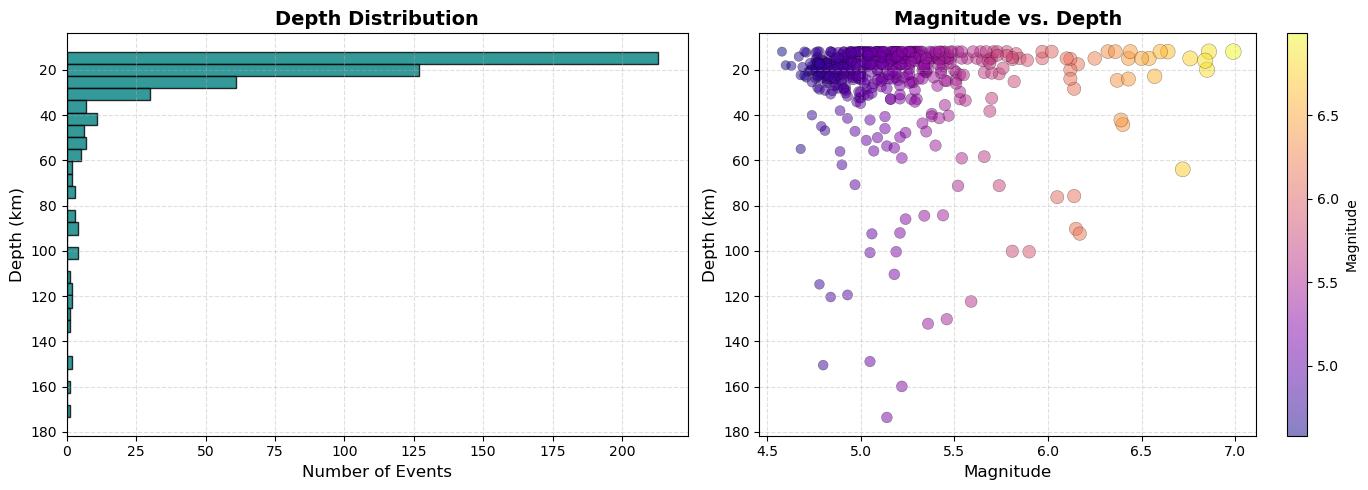

Depth range: 12.0 – 173.6 km
Median depth: 18.4 km
Events with depth data: 496/496


In [12]:
# 3. DEPTH DISTRIBUTION
# Depth tells us about the seismogenic zone thickness and whether
# the sequence is shallow crustal or deeper.

valid_depths = depths[~np.isnan(depths)]

if len(valid_depths) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left: Depth histogram ---
    ax1.hist(valid_depths, bins=30, color='teal', edgecolor='black', alpha=0.8, orientation='horizontal')
    ax1.invert_yaxis()  # Depth increases downward
    ax1.set_ylabel("Depth (km)", fontsize=12)
    ax1.set_xlabel("Number of Events", fontsize=12)
    ax1.set_title("Depth Distribution", fontweight='bold', fontsize=14)
    ax1.grid(True, ls='--', alpha=0.4)
    
    # --- Right: Magnitude vs. Depth ---
    valid_mask = ~np.isnan(depths)
    scatter = ax2.scatter(mags[valid_mask], depths[valid_mask], 
                          c=mags[valid_mask], cmap='plasma', alpha=0.5,
                          s=mags[valid_mask]**2.5, edgecolors='black', linewidth=0.3)
    ax2.invert_yaxis()
    ax2.set_xlabel("Magnitude", fontsize=12)
    ax2.set_ylabel("Depth (km)", fontsize=12)
    ax2.set_title("Magnitude vs. Depth", fontweight='bold', fontsize=14)
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label("Magnitude")
    ax2.grid(True, ls='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('depth_analysis.png')
    plt.show()
    
    print(f"Depth range: {np.nanmin(depths):.1f} – {np.nanmax(depths):.1f} km")
    print(f"Median depth: {np.nanmedian(depths):.1f} km")
    print(f"Events with depth data: {len(valid_depths)}/{len(depths)}")
else:
    print("No depth data available in this catalog.")